In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    📦 INSTALLATION (Run Once)                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
# Run this cell once to install all required packages

%pip install pandas numpy matplotlib statsmodels scipy openpyxl --quiet

# DynaTMT-py-SB (Current version: 2.9.2)
%pip install --upgrade "git+https://github.com/science64/DynaTMT-py-SB.git" --quiet

# PBLMM - Peptide Based Linear Mixed Model (Current version: 2.1.2)
%pip install --upgrade "git+https://github.com/science64/PBLMM.git" --quiet

print("✅ All packages installed successfully!")

# 🧬 mePROD Analysis Pipeline - Complete Template

This notebook provides a comprehensive workflow for analyzing **mePROD (metabolic Protein Dynamics)** data using TMT multiplexing.

## 📋 Workflow Overview

| Step | MS2 Workflow | MS3 Workflow |
|------|-------------|--------------|
| 1 | Load PSMs data | Load PSMs data |
| 2 | Remove booster channel | Remove booster + baseline |
| 3 | Filter PSMs | Filter PSMs |
| 4 | **IT Adjustment** ✓ | Skip IT Adjustment |
| 5 | Normalization | Normalization |
| 6 | Extract Heavy/Light | Extract Heavy/Light |
| 7 | **Baseline Correction** ✓ | PSMs to Peptide (direct) |
| 8 | Statistical Analysis | Statistical Analysis |
| 9 | Export Results | Export Results |

### 🔑 Key Differences
- **MS2**: Requires IT adjustment and baseline correction (higher noise, needs correction)
- **MS3**: Cleaner signal, no IT adjustment needed, skip baseline correction

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                         📚 IMPORT LIBRARIES                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from datetime import date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import DynaTMT_SB.DynaTMT as mePROD
import PBLMM

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

# Check versions
print("╔════════════════════════════════════════╗")
print("║       Package Versions Loaded          ║")
print("╠════════════════════════════════════════╣")
print(f"║  DynaTMT-py-SB: {mePROD.__version__:<20} ║")
print(f"║  Pandas:        {pd.__version__:<20} ║")
print(f"║  NumPy:         {np.__version__:<20} ║")
print("╚════════════════════════════════════════╝")

## ⚙️ Configuration Section

**Important:** Configure all parameters in the cell below before running the analysis!

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                      🎯 CONFIGURATION PARAMETERS                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 WORKFLOW TYPE - Choose your acquisition method
# ═══════════════════════════════════════════════════════════════════════════════
WORKFLOW_TYPE = "MS2"  # Options: "MS2" or "MS3"
                       # MS2: Uses IT adjustment + baseline correction
                       # MS3: Skips IT adjustment, direct PSM to peptide conversion

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 FILE PATHS
# ═══════════════════════════════════════════════════════════════════════════════
wd = "Example data/MS2_data"  # Working directory with your data
dataName = "20200724_SB_CCCP_ISRIB_Import_PSMs.txt"  # Your PSM file name
nameOfStudy = "CCCP_ISRIB_Import"  # Name for output files

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 TMT CHANNEL CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════
# Define channels to remove (booster, baseline, empty channels)
# Set to None if no channel needs to be removed
BOOSTER_CHANNEL = "Abundance: 131C"  # Booster channel name (set None if no booster)
BASELINE_CHANNEL = "Abundance: 126"  # Baseline channel (MS2: keep for correction, MS3: remove)

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 EXPERIMENTAL CONDITIONS
# ═══════════════════════════════════════════════════════════════════════════════
# Define conditions for each TMT channel (in order after removing booster)
# Example for TMT10: 126, 127N, 127C, 128N, 128C, 129N, 129C, 130N, 130C, 131N
conditions = ['Light', 'DMSO', 'DMSO', 'DMSO', 'CCCP', 'CCCP', 'CCCP', 'CCCP_ISRIB', 'CCCP_ISRIB', 'CCCP_ISRIB']

# Define comparison pairs [Treatment, Control] - Result: log2(Treatment/Control)
pairs = [
    ['CCCP', 'DMSO'],           # Compare CCCP vs DMSO
    ['CCCP_ISRIB', 'DMSO'],     # Compare CCCP+ISRIB vs DMSO  
    ['CCCP_ISRIB', 'CCCP']      # Compare CCCP+ISRIB vs CCCP alone
]

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 NORMALIZATION METHOD
# ═══════════════════════════════════════════════════════════════════════════════
NORMALIZATION_METHOD = "sum"  # Options: "sum", "median", "TMM"
                              # sum: Total intensity normalization (recommended)
                              # median: Median-based normalization
                              # TMM: Trimmed Mean of M-values (Robinson & Oshlack)

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 BASELINE CORRECTION PARAMETERS (MS2 only)
# ═══════════════════════════════════════════════════════════════════════════════
BASELINE_THRESHOLD = 15       # Signal-to-noise threshold (10-20 recommended)
BASELINE_INDEX = 0            # Column index of baseline channel (usually 0 = first channel)
RANDOM_REPLACEMENT = True     # Replace negative values with random (0-1) instead of 0

# ═══════════════════════════════════════════════════════════════════════════════
# 🔹 PROTEIN ROLLUP METHOD (if not using PBLMM)
# ═══════════════════════════════════════════════════════════════════════════════
ROLLUP_METHOD = "sum"  # Options: "sum", "mean", "median"

# Print configuration summary
print("╔══════════════════════════════════════════════════════════════╗")
print("║                  CONFIGURATION SUMMARY                       ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Workflow Type:       {WORKFLOW_TYPE:<37} ║")
print(f"║  Working Directory:   {wd:<37} ║")
print(f"║  Data File:           {dataName[:35]:<37} ║")
print(f"║  Normalization:       {NORMALIZATION_METHOD:<37} ║")
print(f"║  Conditions:          {len(conditions)} channels                            ║")
print(f"║  Comparisons:         {len(pairs)} pairs                                ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    📊 HELPER VISUALIZATION FUNCTIONS                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def get_abundance_channels(df):
    """Extract abundance channel columns from dataframe."""
    return [col for col in df.columns 
            if 'abundance' in col.lower() and 'normaliz' not in col.lower()]

def plot_abundance_distribution(df, title="TMT Channel Distribution", figsize=(12, 5)):
    """Create a comprehensive visualization of abundance distribution."""
    channels = get_abundance_channels(df)
    abundance_df = df[channels].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Box plot
    ax1 = axes[0]
    bp = abundance_df.boxplot(ax=ax1, grid=False, vert=True, showfliers=False,
                              patch_artist=True, return_type='dict')
    
    # Color the boxes
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(channels)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.set_title(f"{title}\n(Box Plot)", fontsize=11, fontweight='bold')
    ax1.set_ylabel("Abundance Value", fontsize=10)
    ax1.set_xlabel("TMT Channels", fontsize=10)
    ax1.tick_params(axis='x', rotation=45)
    
    # Summary statistics bar plot
    ax2 = axes[1]
    channel_sums = abundance_df.sum()
    bars = ax2.bar(range(len(channels)), channel_sums.values, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_title(f"{title}\n(Total Intensity per Channel)", fontsize=11, fontweight='bold')
    ax2.set_ylabel("Total Intensity", fontsize=10)
    ax2.set_xlabel("TMT Channels", fontsize=10)
    ax2.set_xticks(range(len(channels)))
    ax2.set_xticklabels([c.split(':')[-1].strip() if ':' in c else c.split()[-1] for c in channels], rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n📈 Data Statistics for: {title}")
    print(f"   └─ Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
    print(f"   └─ Total Intensity Range: {channel_sums.min():,.0f} - {channel_sums.max():,.0f}")
    print(f"   └─ CV between channels: {(channel_sums.std() / channel_sums.mean() * 100):.1f}%")
    return abundance_df

def compare_normalizations(df, process):
    """Compare different normalization methods visually."""
    print("🔄 Comparing normalization methods...")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    methods = {
        'Original': df,
        'Sum Normalization': process.total_intensity_normalisation(df.copy()),
        'Median Normalization': process.Median_normalisation(df.copy()),
        'TMM Normalization': process.TMM(df.copy())
    }
    
    for idx, (name, data) in enumerate(methods.items()):
        ax = axes[idx // 2, idx % 2]
        channels = get_abundance_channels(data)
        abundance_df = data[channels]
        
        bp = abundance_df.boxplot(ax=ax, grid=False, vert=True, showfliers=False,
                                   patch_artist=True, return_type='dict')
        colors = plt.cm.Set2(np.linspace(0, 1, len(channels)))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        channel_sums = abundance_df.sum()
        cv = (channel_sums.std() / channel_sums.mean() * 100)
        ax.set_title(f"{name}\nCV: {cv:.1f}%", fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel("Abundance")
    
    plt.suptitle("📊 Normalization Method Comparison", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return methods

def print_step_header(step_num, title, icon="🔹"):
    """Print a formatted step header."""
    print(f"\n{'═'*70}")
    print(f"{icon} STEP {step_num}: {title}")
    print(f"{'═'*70}")

print("✅ Helper functions loaded successfully!")

---
## 📂 Step 1: Data Loading & Initial Exploration

Load your PSM data and visualize the raw distribution to understand your starting point.

boster_removed: 203381 rows x 47 columns


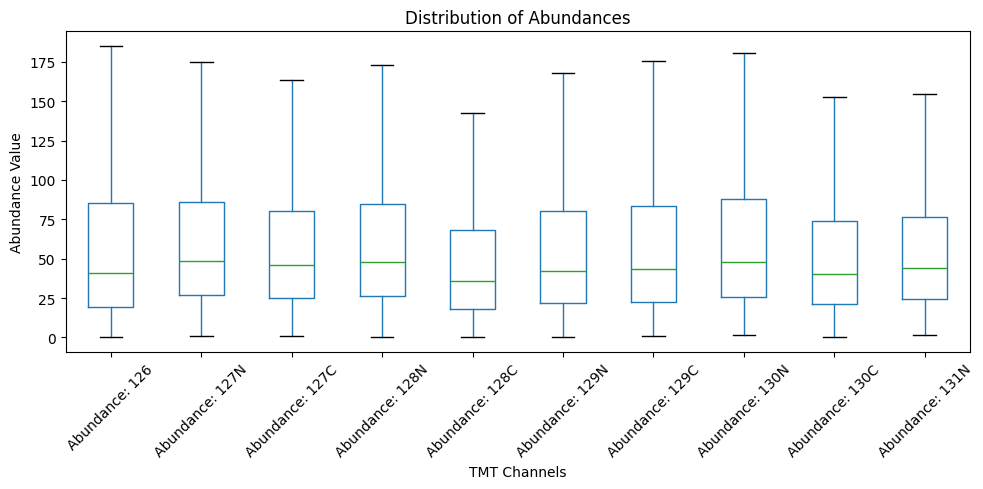

In [ ]:
print_step_header(1, "DATA LOADING", "📂")

# Load the PSM data
psms = pd.read_csv(f'{wd}/{dataName}', sep='\t', header=0)

# For Excel files, use:
# psms = pd.read_excel(f'{wd}/{dataName}', header=0)

print(f"✅ Data loaded successfully!")
print(f"   └─ File: {dataName}")
print(f"   └─ Shape: {psms.shape[0]:,} PSMs × {psms.shape[1]} columns")

# Display available abundance channels
channels = get_abundance_channels(psms)
print(f"\n📋 Detected {len(channels)} abundance channels:")
for i, ch in enumerate(channels):
    print(f"   {i}: {ch}")

# Show raw data distribution
plot_abundance_distribution(psms, "Raw Data - Before Processing")

---
## 🧹 Step 2: Channel Removal (Booster/Baseline)

Remove channels that shouldn't be included in the analysis:
- **Booster channel**: High-intensity spike-in for detection (always remove)
- **Baseline channel**: 
  - **MS2**: Keep for baseline correction (remove later)
  - **MS3**: Remove now (not needed for correction)

Calling function: IT_adjustment
IT_adjusted: 164518 rows x 47 columns


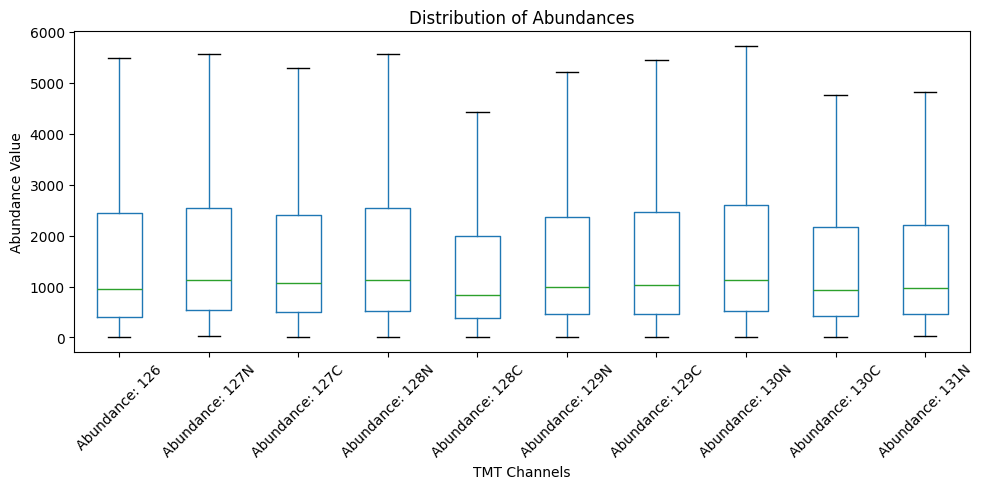

In [ ]:
print_step_header(2, "CHANNEL REMOVAL", "🧹")

# Start with original data
working_data = psms.copy()

# Remove booster channel if specified
if BOOSTER_CHANNEL is not None and BOOSTER_CHANNEL in working_data.columns:
    working_data = working_data.drop(BOOSTER_CHANNEL, axis=1)
    print(f"✅ Removed booster channel: {BOOSTER_CHANNEL}")
else:
    print(f"ℹ️ No booster channel removed (not found or not specified)")

# For MS3: Also remove baseline channel now
if WORKFLOW_TYPE == "MS3":
    if BASELINE_CHANNEL is not None and BASELINE_CHANNEL in working_data.columns:
        working_data = working_data.drop(BASELINE_CHANNEL, axis=1)
        print(f"✅ Removed baseline channel (MS3 workflow): {BASELINE_CHANNEL}")
else:
    print(f"ℹ️ Keeping baseline channel for MS2 baseline correction: {BASELINE_CHANNEL}")

# Show updated distribution
plot_abundance_distribution(working_data, f"After Channel Removal ({WORKFLOW_TYPE} Workflow)")

---
## 🔍 Step 3: Data Filtering

Apply quality filters to remove:
- ❌ Shared peptides (mapped to multiple proteins)
- ❌ Contaminant proteins  
- ❌ Rows with missing values in abundance channels
- ❌ PSMs with high isolation interference (>50%)

Calling function: Median_normalisation
medianNorm: 164518 rows x 47 columns


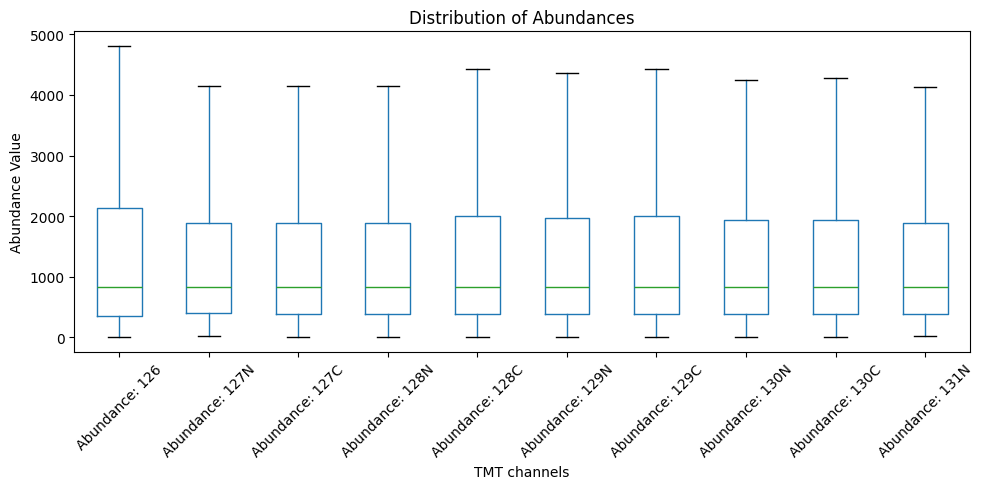

In [ ]:
print_step_header(3, "DATA FILTERING", "🔍")

# Initialize the processor
process = mePROD.PD_input(working_data)

# Filter PSMs
filter_data = process.filter_PSMs(working_data)

# Report filtering results
removed = working_data.shape[0] - filter_data.shape[0]
pct_removed = (removed / working_data.shape[0]) * 100

print(f"\n📊 Filtering Summary:")
print(f"   └─ Before: {working_data.shape[0]:,} PSMs")
print(f"   └─ After:  {filter_data.shape[0]:,} PSMs")
print(f"   └─ Removed: {removed:,} PSMs ({pct_removed:.1f}%)")

# Visualize
plot_abundance_distribution(filter_data, "After Quality Filtering")

---
## ⚡ Step 4: IT Adjustment (MS2 Only)

**Ion Injection Time (IT) Adjustment** compensates for different injection times across PSMs.
- Essential for **MS2** data where IT varies significantly
- **Skip for MS3** data (more consistent acquisition)

Calling function: extract_heavy
Extraction Done Extracted Heavy PSMs/Peptides: 65547
heavy: 65547 rows x 47 columns


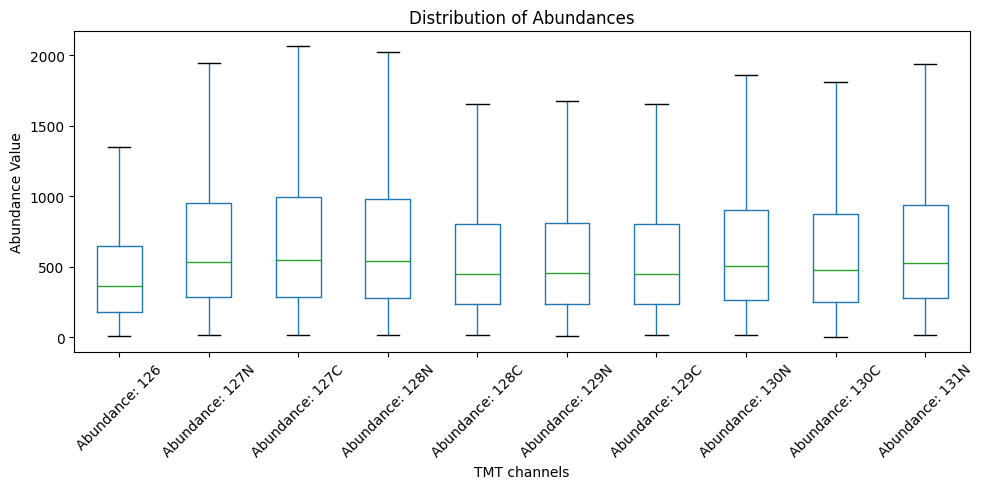

In [ ]:
print_step_header(4, "IT ADJUSTMENT", "⚡")

if WORKFLOW_TYPE == "MS2":
    IT_adjusted = process.IT_adjustment(filter_data)
    print("✅ IT adjustment applied (MS2 workflow)")
    plot_abundance_distribution(IT_adjusted, "After IT Adjustment (MS2)")
    data_for_norm = IT_adjusted
else:
    print("⏭️ Skipping IT adjustment (MS3 workflow - not needed)")
    data_for_norm = filter_data
    print(f"   └─ Using filtered data directly for normalization")

---
## 📊 Step 5: Normalization

Choose from three normalization methods:

| Method | Description | Best For |
|--------|-------------|----------|
| **Sum** | Equalizes total intensity | Most experiments (recommended) |
| **Median** | Equalizes median intensity | Skewed distributions |
| **TMM** | Trimmed Mean of M-values | RNA-seq style normalization |

Run the comparison cell below to visualize all methods, then the normalization cell applies your chosen method.

Calling function: baseline_correction
[#] Decision of this file is: PSMs
Calling function: PSMs_to_Peptide
peptide_data: 31357 rows x 13 columns


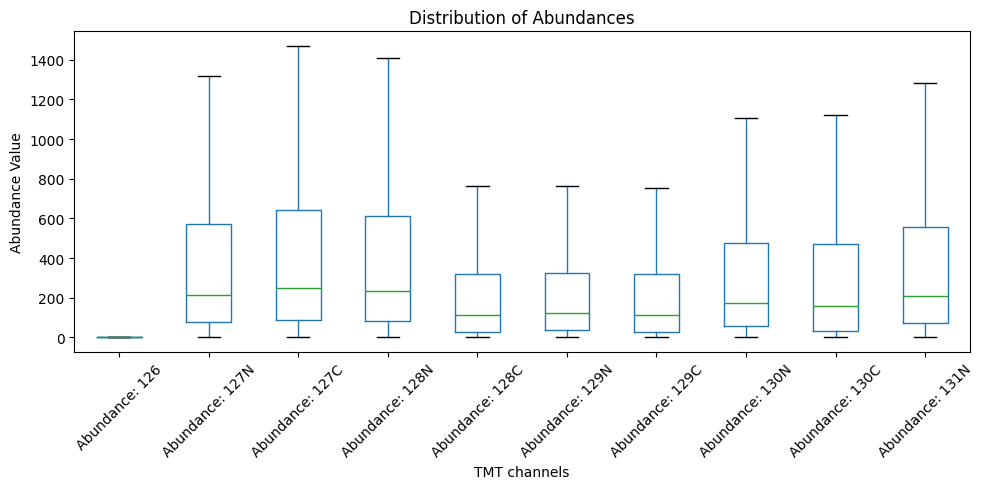

In [ ]:
# Optional: Compare all normalization methods visually
print_step_header("5a", "NORMALIZATION COMPARISON (Optional)", "📊")

norm_methods = compare_normalizations(data_for_norm, process)

print("\n📋 Recommendation:")
print("   └─ Look for the method with lowest CV (coefficient of variation)")
print("   └─ Lower CV = more consistent intensities across channels")

In [ ]:
# Apply selected normalization method
print_step_header("5b", f"APPLYING {NORMALIZATION_METHOD.upper()} NORMALIZATION", "📊")

if NORMALIZATION_METHOD == "sum":
    normalized_data = process.total_intensity_normalisation(data_for_norm)
    print("✅ Applied: Total Intensity (Sum) Normalization")
elif NORMALIZATION_METHOD == "median":
    normalized_data = process.Median_normalisation(data_for_norm)
    print("✅ Applied: Median Normalization")
elif NORMALIZATION_METHOD == "TMM":
    normalized_data = process.TMM(data_for_norm)
    print("✅ Applied: TMM Normalization")
else:
    normalized_data = process.total_intensity_normalisation(data_for_norm)
    print("⚠️ Unknown method, defaulting to Sum Normalization")

plot_abundance_distribution(normalized_data, f"After {NORMALIZATION_METHOD.upper()} Normalization")

---
## 🏷️ Step 6: Heavy/Light Peptide Extraction

Separate peptides based on SILAC labeling:
- **Heavy peptides**: Newly synthesized proteins (contains Label/TMTK modifications)
- **Light peptides**: Pre-existing proteins (no SILAC label)

For mePROD analysis, we primarily use **heavy** peptides.

In [ ]:
print_step_header(6, "HEAVY/LIGHT EXTRACTION", "🏷️")

# Extract heavy peptides (main analysis)
heavy = process.extract_heavy(normalized_data)

# Extract light peptides (optional - for total protein analysis)
light = process.extract_light(normalized_data)

# Summary
print(f"\n📊 Extraction Summary:")
print(f"   └─ Heavy PSMs: {heavy.shape[0]:,} ({heavy.shape[0]/normalized_data.shape[0]*100:.1f}%)")
print(f"   └─ Light PSMs: {light.shape[0]:,} ({light.shape[0]/normalized_data.shape[0]*100:.1f}%)")

# Visualize heavy peptides
plot_abundance_distribution(heavy, "Heavy Peptides (Newly Synthesized)")

---
## 🔧 Step 7: Baseline Correction / PSM to Peptide Conversion

**MS2 Workflow:** Apply baseline correction to remove noise, then convert to peptides
- Subtracts baseline channel from all samples
- Applies signal-to-noise threshold
- Converts PSMs to peptide level

**MS3 Workflow:** Direct conversion from PSMs to peptides (baseline already removed)

In [ ]:
print_step_header(7, "BASELINE CORRECTION / PSM TO PEPTIDE", "🔧")

if WORKFLOW_TYPE == "MS2":
    print(f"🔹 MS2 Workflow: Applying baseline correction")
    print(f"   └─ Threshold: {BASELINE_THRESHOLD}")
    print(f"   └─ Baseline index: {BASELINE_INDEX}")
    print(f"   └─ Random replacement: {RANDOM_REPLACEMENT}")
    
    peptide_data = process.baseline_correction(
        heavy, 
        threshold=BASELINE_THRESHOLD, 
        i_baseline=BASELINE_INDEX, 
        random=RANDOM_REPLACEMENT
    )
    print(f"\n✅ Baseline correction applied and PSMs converted to peptides")
    
else:  # MS3
    print(f"🔹 MS3 Workflow: Direct PSM to Peptide conversion (no baseline correction)")
    peptide_data = process.PSMs_to_Peptide(heavy)
    print(f"\n✅ PSMs converted to peptides")

print(f"\n📊 Peptide Data Summary:")
print(f"   └─ Peptides: {peptide_data.shape[0]:,}")
print(f"   └─ Columns: {peptide_data.shape[1]}")

# Visualize peptide data
plot_abundance_distribution(peptide_data, f"Peptide Level Data ({WORKFLOW_TYPE})")

No Normalization applied
Calculate Protein quantifications from PSM
Combination done
Total Number of Datapoints:  313570
['CCCP', 'DMSO'] and decision: -1
['CCCP_ISRIB', 'DMSO'] and decision: -1
['CCCP_ISRIB', 'CCCP'] and decision: 1
resultFinal: 5144 rows x 20 columns
CPU times: total: 6min 54s
Wall time: 7min 16s


---
## 📈 Step 8: Statistical Analysis (PBLMM)

**Peptide-Based Linear Mixed Model (PBLMM)** performs statistical testing:
- Uses peptide-level data for robust statistics
- Accounts for protein as random effect
- Calculates fold changes and p-values for each comparison

In [ ]:
%%time
print_step_header(8, "STATISTICAL ANALYSIS (PBLMM)", "📈")

print(f"🔹 Running Peptide-Based Linear Mixed Model...")
print(f"   └─ Conditions: {conditions}")
print(f"   └─ Comparisons: {pairs}")

# Run PBLMM analysis
hypothesis_testing = PBLMM.HypothesisTesting()
resultFinal = hypothesis_testing.peptide_based_lmm(
    peptide_data,
    conditions=conditions,
    pairs=pairs
)

# Clean up result
resultFinal.reset_index(inplace=True)
resultFinal.rename(columns={'index': 'Accession'}, inplace=True)

print(f"\n✅ Analysis completed!")
print(f"   └─ Proteins analyzed: {resultFinal.shape[0]:,}")
print(f"   └─ Output columns: {resultFinal.shape[1]}")

# Display preview
print(f"\n📋 Result Preview:")
display(resultFinal.head(10))

---
## 📊 Step 9: Results Visualization

Visualize the statistical results with volcano plots and summary statistics.

In [ ]:
print_step_header(9, "RESULTS VISUALIZATION", "📊")

# Create volcano plots for each comparison
n_pairs = len(pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(5*n_pairs, 5))
if n_pairs == 1:
    axes = [axes]

for idx, pair in enumerate(pairs):
    ax = axes[idx]
    
    # Get column names for this comparison
    fc_col = [c for c in resultFinal.columns if f'log2FC' in c and pair[0] in c and pair[1] in c]
    pval_col = [c for c in resultFinal.columns if 'pvalue' in c.lower() and pair[0] in c and pair[1] in c]
    
    if fc_col and pval_col:
        fc_col = fc_col[0]
        pval_col = pval_col[0]
        
        # Calculate -log10(pvalue)
        log_pval = -np.log10(resultFinal[pval_col].replace(0, 1e-300))
        
        # Color based on significance
        colors = np.where(
            (np.abs(resultFinal[fc_col]) > 1) & (resultFinal[pval_col] < 0.05),
            'red',
            np.where(resultFinal[pval_col] < 0.05, 'orange', 'gray')
        )
        
        ax.scatter(resultFinal[fc_col], log_pval, c=colors, alpha=0.5, s=10)
        ax.axhline(y=-np.log10(0.05), color='blue', linestyle='--', linewidth=1, label='p=0.05')
        ax.axvline(x=-1, color='green', linestyle='--', linewidth=1)
        ax.axvline(x=1, color='green', linestyle='--', linewidth=1)
        
        ax.set_xlabel('log2 Fold Change', fontsize=10)
        ax.set_ylabel('-log10(p-value)', fontsize=10)
        ax.set_title(f'{pair[0]} vs {pair[1]}', fontsize=11, fontweight='bold')
        
        # Count significant
        sig_up = ((resultFinal[fc_col] > 1) & (resultFinal[pval_col] < 0.05)).sum()
        sig_down = ((resultFinal[fc_col] < -1) & (resultFinal[pval_col] < 0.05)).sum()
        ax.text(0.02, 0.98, f'↑ {sig_up}\n↓ {sig_down}', transform=ax.transAxes, 
                fontsize=9, verticalalignment='top', fontweight='bold')

plt.suptitle('🌋 Volcano Plots - Statistical Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊 Significance Summary (|log2FC| > 1, p < 0.05):")
for pair in pairs:
    fc_col = [c for c in resultFinal.columns if f'log2FC' in c and pair[0] in c and pair[1] in c]
    pval_col = [c for c in resultFinal.columns if 'pvalue' in c.lower() and pair[0] in c and pair[1] in c]
    if fc_col and pval_col:
        fc_col, pval_col = fc_col[0], pval_col[0]
        sig = ((np.abs(resultFinal[fc_col]) > 1) & (resultFinal[pval_col] < 0.05)).sum()
        print(f"   └─ {pair[0]} vs {pair[1]}: {sig} significant proteins")

---
## 💾 Step 10: Export Results

Save the final results to Excel file with date stamp.

In [ ]:
print_step_header(10, "EXPORT RESULTS", "💾")

# Generate output filename
output_filename = f"{nameOfStudy}_mePROD_PBLMM_{WORKFLOW_TYPE}_{date.today().strftime('%d.%m.%Y')}.xlsx"
output_path = f"{wd}/{output_filename}"

# Export to Excel
resultFinal.to_excel(output_path, index=False, engine='openpyxl')

print(f"✅ Results exported successfully!")
print(f"   └─ File: {output_filename}")
print(f"   └─ Path: {output_path}")
print(f"   └─ Proteins: {resultFinal.shape[0]:,}")
print(f"   └─ Columns: {resultFinal.shape[1]}")

print("\n" + "═"*70)
print("🎉 ANALYSIS COMPLETE!")
print("═"*70)

---
## 🔄 Alternative: Protein Rollup (Without PBLMM)

If you prefer to use your own statistical analysis, use this section to:
1. Roll up peptides to protein level
2. Export protein-level data for external analysis

In [ ]:
# OPTIONAL: Protein rollup without PBLMM
# Uncomment and run this cell if you want to do your own statistical analysis

# print_step_header("ALT", f"PROTEIN ROLLUP ({ROLLUP_METHOD.upper()})", "🔄")

# protein_data = process.protein_rollup(peptide_data, method=ROLLUP_METHOD)

# print(f"✅ Peptides rolled up to proteins using {ROLLUP_METHOD} method")
# print(f"   └─ Proteins: {protein_data.shape[0]:,}")

# # Visualize protein data
# plot_abundance_distribution(protein_data, f"Protein Level Data ({ROLLUP_METHOD})")

# # Export protein data
# protein_output = f"{nameOfStudy}_Proteins_{ROLLUP_METHOD}_{WORKFLOW_TYPE}_{date.today().strftime('%d.%m.%Y')}.xlsx"
# protein_data.to_excel(f"{wd}/{protein_output}", engine='openpyxl')
# print(f"\n💾 Exported: {protein_output}")